# 03 · Scorecard tradicional PD — Caso 15 · Caja Rural 360

**Alcance:** sección **6.5** del Trabajo Integrador Final: clasificación en tramos (binning), WOE, IV, regresión logística y transformación a una escala de puntos. La narrativa está en `reports/05_scorecard_tradicional.md`.

**Regla de uso de muestras** (coherente con 6.2, 6.3 y 6.4). Todo lo que aprende del dato —tramos, WOE y coeficientes— se ajusta con **DEV (2021-2023)**. Los parámetros del binning se afinan con **validación temporal dentro de DEV** (tramos ajustados en 2021-2022 y evaluados en 2023). **VAL (2024)** se usa solo para lo que 6.2 permite: comprobar que ninguna característica se invierta fuera de DEV y elegir entre dos especificaciones fijadas de antemano. De la cosecha **OOT (2025)** solo se usa el PSI, que no necesita target: su desempeño se mide una sola vez en 6.7.

**Convenciones.** WOE = ln(%buenos / %malos), así que **WOE alto = menos riesgo**. La logística modela la probabilidad de default: todos los coeficientes deben salir **negativos**, y uno positivo delataría colinealidad. Los faltantes reciben **WOE neutral (0)**, como se decidió en 6.3. Score alto = menos riesgo.

| Sección | Contenido |
|---|---|
| 1 | Parámetros del binning, afinados con validación temporal dentro de DEV |
| 2 | Binning, WOE e IV de las 22 candidatas y criterios S1-S7 |
| 3 | Selección multivariada y especificaciones pre-registradas |
| 4 | Scorecard final: coeficientes, puntos y escala |
| 5 | Desempeño en DEV y VAL, bandas de score y estabilidad |
| 6 | Calibración: la PD de desarrollo no es la PD de producción |
| 7 | Sesgo de selección: sensibilidad con reject inference |
| 8 | Razones de decisión (reason codes) |
| 9 | Resumen y trazabilidad de 6.5 |

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from src import config as cfg, data, eda, features, scorecard as sc, validation

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
for d in (cfg.FIGURES, cfg.TABLES):
    d.mkdir(parents=True, exist_ok=True)

BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK_2, MUTED, GRID, AXIS, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK_2, "xtick.color": MUTED, "ytick.color": MUTED,
    "text.color": INK, "axes.titlecolor": INK, "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "axes.grid": True, "grid.color": GRID, "grid.linestyle": "-",
    "grid.linewidth": 0.6, "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 9.5, "legend.frameon": False, "figure.dpi": 100,
})

def savefig(fig, name):
    fig.savefig(cfg.FIGURES / f"{name}.png", dpi=150, bbox_inches="tight")

def pct_axis(ax, axis="y", decimals=0):
    a = ax.yaxis if axis == "y" else ax.xaxis
    a.set_major_locator(plt.MaxNLocator(nbins=6, steps=[1, 2, 5, 10]))
    a.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.{decimals}%}"))

def barras_con_ic(ax, x, tasa, lo, hi, color, ancho=0.38, desplazamiento=0.0, etiqueta=None, valores=True):
    pos = np.arange(len(x)) + desplazamiento
    ax.bar(pos, tasa, width=ancho, color=color, label=etiqueta)
    ax.errorbar(pos, tasa, yerr=[np.asarray(tasa) - np.asarray(lo), np.asarray(hi) - np.asarray(tasa)],
                fmt="none", ecolor=INK_2, elinewidth=0.9, capsize=2)
    if valores:
        for p_, v in zip(pos, tasa):
            ax.text(p_, v, f"{v:.1%}", ha="center", va="bottom", fontsize=8, color=INK_2)
    return pos

print("Raíz del repositorio:", ROOT)

Raíz del repositorio: /home/claude/work/Proyecto_Final_Credit_Scoring-main


In [2]:
from scipy import stats
from sklearn.linear_model import LogisticRegression

raw = data.load_raw()
pop, _ = data.pd_population(raw)
fx = features.build_features(pop)
T = cfg.TARGET
dev, val, oot = (fx[fx["sample"] == s].copy() for s in cfg.SAMPLE_ORDER)
muestras = {"DEV": dev, "VAL": val}
candidatas = data.pd_candidate_features() + features.DERIVED_CANDIDATES
(cfg.ROOT / "models").mkdir(exist_ok=True)
print(f"DEV: {len(dev):,} créditos, {int(dev[T].sum())} defaults ({dev[T].mean():.1%}) | VAL: {len(val):,}, {int(val[T].sum())} defaults ({val[T].mean():.1%})"
      f" | OOT: {len(oot):,} créditos (en esta sección solo se usa su distribución, sin target)")
print(f"Candidatas: {len(candidatas)} (20 del catálogo de 6.2 + {', '.join(features.DERIVED_CANDIDATES)} de 6.3)")
print("Excluidas por diseño (fairness):", list(sc.EXCLUDED_BY_DESIGN))

DEV: 3,443 créditos, 351 defaults (10.2%) | VAL: 1,151, 161 defaults (14.0%) | OOT: 1,189 créditos (en esta sección solo se usa su distribución, sin target)
Candidatas: 22 (20 del catálogo de 6.2 + dti_post, ahorro_sobre_monto de 6.3)
Excluidas por diseño (fairness): ['age', 'region', 'distance_to_branch_km', 'household_dependents', 'cash_income_share']


## 1. Parámetros del binning

La clasificación fina parte de 20 cuantiles (o de cada valor cuando la variable tiene pocos) y después agrupa tramos con reglas fijadas antes de mirar resultados:

- cada tramo con al menos **5% de DEV y 15 defaults** (con 351 defaults, el error estándar del WOE de un tramo queda por debajo de ~0.27);
- **tendencia monótona** en la dirección de negocio esperada (`scorecard.EXPECTED_TREND`);
- como máximo **6 tramos**;
- tramos contiguos con riesgo prácticamente igual (diferencia de log-odds < 0.05) se fusionan, porque separarlos no aporta y ensucia la tabla de puntos.

Queda una decisión abierta: si además se fusionan los tramos contiguos cuya diferencia **no es estadísticamente significativa**. Con 351 defaults esa regla puede agrupar de más. Se decide con validación temporal dentro de DEV, usando las tres variables núcleo que identificó la EDA (buró, capacidad de pago y ahorro).

In [3]:
# Validación temporal dentro de DEV: tramos ajustados en 2021-2022, evaluados en 2023.
a = dev[dev[cfg.DATE_COL] <= "2022-12-31"]
b = dev[dev[cfg.DATE_COL] >= "2023-01-01"]
nucleo = ["bureau_score", "dti_post", "ahorro_sobre_monto"]
filas = []
for alfa in [0.05, 0.10, 0.20, None]:
    tr = {v: sc.fit_binning(a, v, merge_alpha=alfa) for v in nucleo}
    Wa, Wb = sc.woe_frame(a, tr, nucleo), sc.woe_frame(b, tr, nucleo)
    m = LogisticRegression(penalty=None, max_iter=5000).fit(Wa, a[T])
    p_a, p_b = m.predict_proba(Wa)[:, 1], m.predict_proba(Wb)[:, 1]
    fila = {"fusion_por_significancia": "No" if alfa is None else f"Sí, alfa {alfa}"}
    fila.update({f"tramos_{v}": len(tr[v].woe) for v in nucleo})
    fila.update({"gini_2021_2022": validation.gini(a[T], p_a), "gini_2023": validation.gini(b[T], p_b),
                 "puntajes_distintos_2023": len(np.unique(np.round(p_b, 10)))})
    for v in nucleo:   # ¿se mantiene en 2023 el orden de los tramos? (Spearman WOE vs default; -1 = orden perfecto)
        t = tr[v].table(b[v], b[T]); t = t[t["orden"] >= 0]
        fila[f"orden_2023_{v}"] = stats.spearmanr(t["woe"], t["default_rate"])[0] if len(t) > 2 else np.nan
    filas.append(fila)
tuning = pd.DataFrame(filas).set_index("fusion_por_significancia")
display(tuning)
tuning.to_csv(cfg.TABLES / "scorecard_binning_tuning.csv")

,tramos_bureau_score,tramos_dti_post,tramos_ahorro_sobre_monto,gini_2021_2022,gini_2023,puntajes_distintos_2023,orden_2023_bureau_score,orden_2023_dti_post,orden_2023_ahorro_sobre_monto
fusion_por_significancia,,,,,,,,,
"Sí, alfa 0.05",4,2,1,0.3945,0.3950,22,-1.0000,NaN,NaN
"Sí, alfa 0.1",4,3,2,0.4222,0.4218,47,-1.0000,-1.0000,NaN
"Sí, alfa 0.2",4,3,2,0.4222,0.4218,47,-1.0000,-1.0000,NaN
No,5,4,4,0.4249,0.4331,112,-1.0000,-1.0000,-0.8000


## 1. Parámetros del binning

La clasificación fina parte de 20 cuantiles (o de cada valor cuando la variable tiene pocos) y después agrupa tramos con reglas fijadas antes de mirar resultados:

- cada tramo con al menos **5% de DEV y 15 defaults** (con 351 defaults, el error estándar del WOE de un tramo queda por debajo de ~0.27);
- **tendencia monótona** en la dirección de negocio esperada (`scorecard.EXPECTED_TREND`);
- como máximo **6 tramos**;
- tramos contiguos con riesgo prácticamente igual (diferencia de log-odds < 0.05) se fusionan, porque separarlos no aporta y ensucia la tabla de puntos.

Queda una decisión abierta: si además se fusionan los tramos contiguos cuya diferencia **no es estadísticamente significativa**. Con 351 defaults esa regla puede agrupar de más. Se decide con validación temporal dentro de DEV, usando las tres variables núcleo que identificó la EDA (buró, capacidad de pago y ahorro)._LECTURA

## 2. Binning, WOE e IV de las 22 candidatas

Cada candidata se convierte en tramos con esas reglas y se mide su IV en DEV. El IV se acompaña de una **prueba de permutación**: se repite el mismo binning con el target permutado 200 veces y se compara el IV observado con el que produce el azar. Sin ese contraste, el IV engaña, porque el binning "busca" separación y sobre ruido también produce IV > 0.

Una variable entra al scorecard si cumple los siete criterios (`scorecard.SELECTION_CRITERIA`), fijados antes de ver los resultados:

In [4]:
display(pd.DataFrame({"criterio": list(sc.SELECTION_CRITERIA.values())}, index=pd.Index(list(sc.SELECTION_CRITERIA), name="regla")))
seleccion, tramos = sc.univariate_selection(dev, val, oot, candidatas)
display(seleccion)
seleccion.to_csv(cfg.TABLES / "scorecard_seleccion_univariada.csv", index=False)
con_poder = seleccion.loc[seleccion["S1"], "variable"].tolist()
detalle = pd.concat([tramos[v].table(dev[v], dev[T]).assign(muestra="DEV") for v in con_poder]
                    + [tramos[v].table(val[v], val[T]).assign(muestra="VAL (información)") for v in con_poder])
detalle.to_csv(cfg.TABLES / "scorecard_tramos_woe.csv", index=False)
print("Pasan S1-S7:", seleccion.loc[seleccion["pasa"], "variable"].tolist())

,criterio
regla,
S1,Poder en DEV: IV >= 0.02
S2,El IV no es un artefacto del binning: prueba d...
S3,Dirección del riesgo con sentido de negocio do...
S4,El tramo de más riesgo supera al de menos ries...
S5,Distribución de tramos estable: PSI DEV->VAL y...
S6,No se invierte en VAL: con los tramos y WOE de...
S7,No está excluida por diseño (fairness: proxy s...


,variable,tipo,tramos,iv_dev,poder,p_permutacion,tendencia,psi_val,psi_oot,iv_val_info,S1,S2,S3,S4,S5,S6,S7,pasa,no_cumple
0,bureau_score,numérica,6,0.4941,Fuerte,0.0050,-,0.0069,0.0087,0.3987,True,True,True,True,True,True,True,True,
1,dti_post,numérica,4,0.0904,Débil,0.0050,+,0.0038,0.0007,0.0486,True,True,True,True,True,True,True,True,
2,dti,numérica,4,0.0889,Débil,0.0050,+,0.0019,0.0021,0.0110,True,True,True,True,True,True,True,True,
3,ahorro_sobre_monto,numérica,3,0.0470,Débil,0.0050,-,0.0020,0.0030,0.0335,True,True,True,True,True,True,True,True,
4,prior_delinquencies_24m,numérica,3,0.0299,Débil,0.0050,+,0.0011,0.0002,-0.0076,True,True,True,True,True,False,True,False,S6
5,monthly_debt_payment,numérica,4,0.0278,Débil,0.0249,+,0.0031,0.0011,0.0256,True,True,True,True,True,True,True,True,
6,region,categórica,4,0.0232,Débil,0.0945,por categoría,0.0062,0.0004,0.0170,True,False,True,True,True,True,False,False,"S2, S7"
7,savings_balance,numérica,4,0.0208,Débil,0.0746,-,0.0028,0.0064,0.0026,True,False,True,True,True,True,True,False,S2
8,employment_tenure_months,numérica,5,0.0129,Sin poder,NaN,-,0.0129,0.0035,-0.0020,False,False,True,True,True,False,True,False,"S1, S2, S6"
9,term_months,numérica,2,0.0113,Sin poder,NaN,-,0.0000,0.0000,0.0067,False,False,False,True,True,True,True,False,"S1, S2, S3"


Pasan S1-S7: ['bureau_score', 'dti_post', 'dti', 'ahorro_sobre_monto', 'monthly_debt_payment']


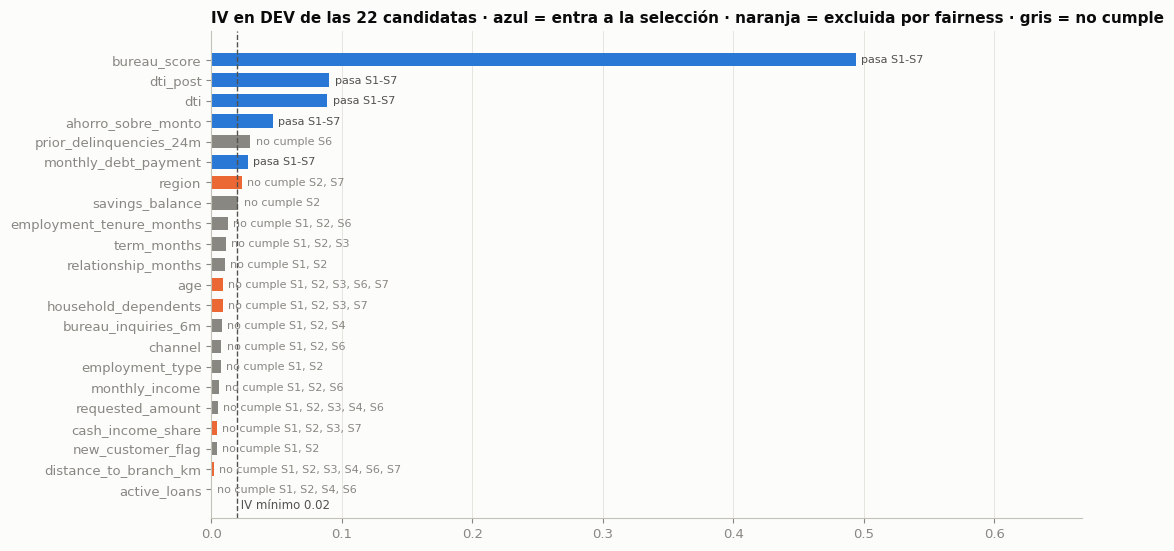

In [5]:
fig, ax = plt.subplots(figsize=(11, 5.6))
s_ = seleccion.sort_values("iv_dev")
colores = [BLUE if r["pasa"] else (ORANGE if not r["S7"] else MUTED) for _, r in s_.iterrows()]
ax.barh(s_["variable"], s_["iv_dev"], color=colores, height=0.65)
ax.axvline(sc.IV_MIN, color=INK_2, lw=1, ls="--")
ax.text(sc.IV_MIN, -0.75, f" IV mínimo {sc.IV_MIN}", color=INK_2, fontsize=8.5, va="center")
for y_, (_, r) in enumerate(s_.iterrows()):
    ax.text(r["iv_dev"] + 0.004, y_, "pasa S1-S7" if r["pasa"] else "no cumple " + r["no_cumple"], va="center", fontsize=8,
            color=INK_2 if r["pasa"] else MUTED)
ax.set_xlim(0, s_["iv_dev"].max() * 1.35)
ax.set_title("IV en DEV de las 22 candidatas · azul = entra a la selección · naranja = excluida por fairness · gris = no cumple")
ax.grid(axis="y", visible=False)
fig.tight_layout(); savefig(fig, "fig19_iv_candidatas"); plt.show()

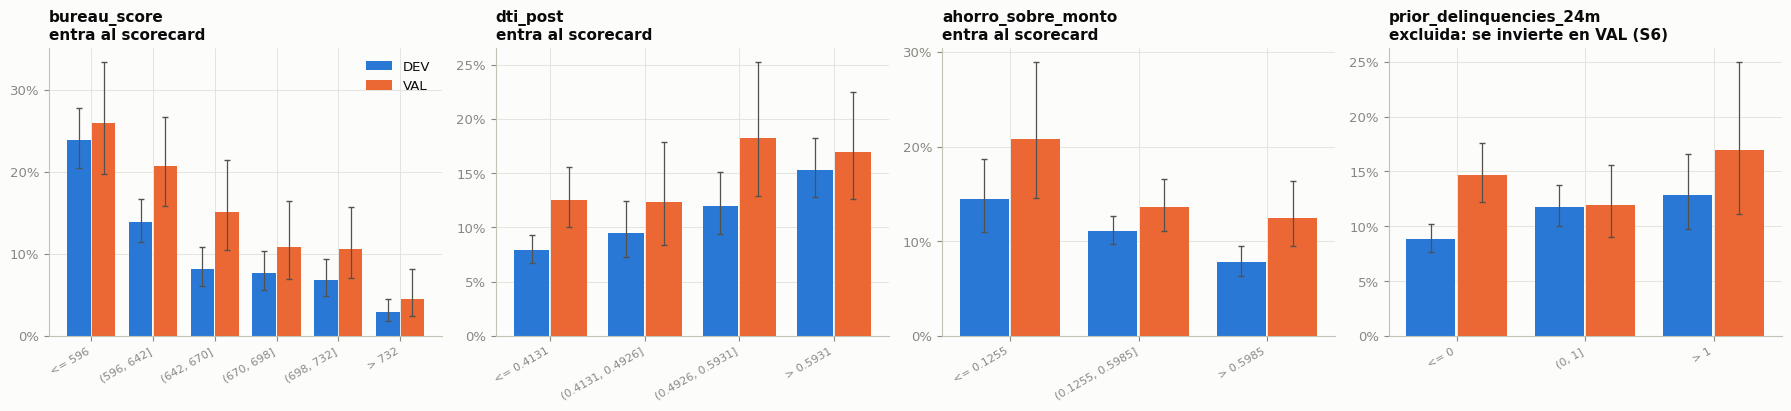

In [6]:
# Tramos de las finalistas y de la mora previa (excluida por S6): default por tramo en DEV y en VAL con IC 95%.
paneles = ["bureau_score", "dti_post", "ahorro_sobre_monto", "prior_delinquencies_24m"]
fig, axes = plt.subplots(1, 4, figsize=(18, 4.2))
for ax, v in zip(axes, paneles):
    t_dev = tramos[v].table(dev[v], dev[T]); t_val = tramos[v].table(val[v], val[T])
    t_dev, t_val = t_dev[t_dev["orden"] >= 0], t_val[t_val["orden"] >= 0]
    for t_, col, desp, et in [(t_dev, BLUE, -0.2, "DEV"), (t_val, ORANGE, 0.2, "VAL")]:
        lo, hi = eda.wilson_ci(t_["defaults"], t_["creditos"])
        barras_con_ic(ax, t_["tramo"], t_["default_rate"], lo, hi, col, desplazamiento=desp, etiqueta=et, valores=False)
    ax.set_xticks(np.arange(len(t_dev)), t_dev["tramo"], rotation=30, ha="right", fontsize=8)
    pct_axis(ax)
    estado = "entra al scorecard" if v in seleccion.loc[seleccion["pasa"], "variable"].tolist() else "excluida: se invierte en VAL (S6)"
    ax.set_title(f"{v}\n{estado}")
axes[0].legend(loc="upper right")
fig.tight_layout(); savefig(fig, "fig20_tramos_finalistas"); plt.show()

Cada candidata se convierte en tramos con esas reglas y se mide su IV en DEV. El IV se acompaña de una **prueba de permutación**: se repite el mismo binning con el target permutado 200 veces y se compara el IV observado con el que produce el azar. Sin ese contraste, el IV engaña, porque el binning "busca" separación y sobre ruido también produce IV > 0.

Una variable entra al scorecard si cumple los siete criterios (`scorecard.SELECTION_CRITERIA`), fijados antes de ver los resultados:_LECTURA

In [7]:
# Faltantes: WOE que habría resultado en DEV frente al WOE neutral asignado por diseño (6.3).
filas = []
buenos_tot, malos_tot = int((dev[T] == 0).sum()), int(dev[T].sum())
for v in ["bureau_score", "dti_post", "ahorro_sobre_monto"]:
    t = tramos[v].table(dev[v], dev[T])
    f = t[t["orden"] == -1].iloc[0]
    woe_obs = np.log(((f["buenos"] + 0.5) / buenos_tot) / ((f["defaults"] + 0.5) / malos_tot))
    filas.append({"variable": v, "creditos_con_faltante": int(f["creditos"]), "defaults": int(f["defaults"]),
                  "default_rate": f["default_rate"], "woe_observado_dev": woe_obs, "woe_asignado": 0.0})
faltantes_woe = pd.DataFrame(filas).set_index("variable")
display(faltantes_woe)
faltantes_woe.to_csv(cfg.TABLES / "scorecard_faltantes_woe.csv")

,creditos_con_faltante,defaults,default_rate,woe_observado_dev,woe_asignado
variable,,,,,
bureau_score,126,6,0.0476,0.7441,0.0000
dti_post,85,7,0.0824,0.1724,0.0000
ahorro_sobre_monto,255,23,0.0902,0.1161,0.0000


**Faltantes: WOE neutral por decisión, no por descuido.** Si se usara el WOE observado en DEV, quien no tiene score de buró recibiría +0.74 de WOE, es decir unos **22 puntos de regalo**, sostenidos por 6 defaults en 126 créditos, y ese menor riesgo se concentra en 2021-2022 y desaparece en 2023 (6.3). Con WOE neutral, la solicitud sin score queda en el promedio de la cartera y la política la manda a revisión con re-consulta del buró. Lo mismo para el ingreso y el ahorro, cuyos faltantes son compatibles con MCAR y cuyo WOE observado es pequeño (+0.17 y +0.12).

## 3. Selección multivariada

El orden es el habitual de un scorecard: primero se descarta redundancia entre características (Spearman sobre los WOE, tope 0.60), después se seleccionan hacia adelante con test de razón de verosimilitud (p < 0.05), exigiendo que **todos los coeficientes queden negativos y significativos** y que el VIF se mantenga por debajo de 2.5.

6.3 dejó una decisión abierta: `dti` y `dti_post` miden lo mismo (Spearman 0.83) y no pueden convivir. Se comparan **dos especificaciones fijadas de antemano** —A con `dti_post`, B con `dti`— y la regla, también fijada antes, es quedarse con **A** (la que reacciona a una contraoferta de monto o plazo y coincide con la regla de capacidad de pago) **salvo que B sea significativamente mejor en VAL**, medido con el intervalo de confianza bootstrap de la diferencia de AUC.

In [8]:
finalistas = seleccion.loc[seleccion["pasa"], "variable"].tolist()
print("Correlación de Spearman entre WOE (DEV):")
display(sc.woe_frame(dev, tramos, finalistas).corr(method="spearman"))

especificaciones = {"A · dti_post": [v for v in finalistas if v != "dti"], "B · dti": [v for v in finalistas if v != "dti_post"]}
resultados, filas = {}, []
for nombre, cands in especificaciones.items():
    pasos = sc.forward_stepwise(dev, tramos, cands)
    vs = pasos["entra"].tolist()
    card_e, coefs_e = sc.fit_scorecard(dev, vs, tramos)
    resultados[nombre] = card_e
    print(f"\nEspecificación {nombre} · candidatas: {cands}")
    display(pasos, coefs_e)
    p_d, p_v = card_e.predict_pd(dev), card_e.predict_pd(val)
    filas.append({"especificacion": nombre, "variables": ", ".join(vs),
                  "gini_dev": validation.gini(dev[T], p_d), "gini_val": validation.gini(val[T], p_v),
                  "ks_dev": validation.ks_statistic(dev[T], p_d), "ks_val": validation.ks_statistic(val[T], p_v),
                  "vif_max": float(sc.vif(sc.woe_frame(dev, tramos, vs)).max())})
comparacion = pd.DataFrame(filas).set_index("especificacion")
dif_ab = validation.paired_bootstrap_auc(val[T], resultados["A · dti_post"].predict_pd(val), resultados["B · dti"].predict_pd(val),
                                         n_boot=1000, seed=cfg.SEED)
comparacion.loc["A · dti_post", ["delta_auc_val_vs_B", "ic_inf", "ic_sup"]] = [dif_ab["delta_auc"], dif_ab["ic_inf"], dif_ab["ic_sup"]]
display(comparacion)
comparacion.to_csv(cfg.TABLES / "scorecard_especificaciones.csv")
print(f"VAL: AUC(A) - AUC(B) = {dif_ab['delta_auc']:+.4f} (IC 95% bootstrap: {dif_ab['ic_inf']:+.4f} a {dif_ab['ic_sup']:+.4f})")

Correlación de Spearman entre WOE (DEV):


,bureau_score,dti_post,dti,ahorro_sobre_monto,monthly_debt_payment
bureau_score,1.0000,-0.0158,-0.0246,-0.0095,-0.0081
dti_post,-0.0158,1.0000,0.7189,0.0731,0.5038
dti,-0.0246,0.7189,1.0000,0.0044,0.6442
ahorro_sobre_monto,-0.0095,0.0731,0.0044,1.0000,-0.0036
monthly_debt_payment,-0.0081,0.5038,0.6442,-0.0036,1.0000



Especificación A · dti_post · candidatas: ['bureau_score', 'dti_post', 'ahorro_sobre_monto', 'monthly_debt_payment']


,paso,entra,p_razon_verosimilitud,log_verosimilitud,vif_max
0,1,bureau_score,0.0000,"-1,057.4340",1.0000
1,2,dti_post,0.0000,"-1,041.0764",1.0002
2,3,ahorro_sobre_monto,0.0010,"-1,035.6341",1.0077


,coef,se,z,p_value
intercepto,-2.2168,0.0619,-35.8190,0.0000
bureau_score,-1.0373,0.0877,-11.8295,0.0000
dti_post,-1.0345,0.1895,-5.4591,0.0000
ahorro_sobre_monto,-0.8880,0.2709,-3.2784,0.0010



Especificación B · dti · candidatas: ['bureau_score', 'dti', 'ahorro_sobre_monto', 'monthly_debt_payment']


,paso,entra,p_razon_verosimilitud,log_verosimilitud,vif_max
0,1,bureau_score,0.0000,"-1,057.4340",1.0000
1,2,dti,0.0000,"-1,039.9822",1.0008
2,3,ahorro_sobre_monto,0.0002,"-1,032.8882",1.0009


,coef,se,z,p_value
intercepto,-2.2190,0.0620,-35.7668,0.0000
bureau_score,-1.0451,0.0878,-11.9046,0.0000
dti,-1.1399,0.1896,-6.0105,0.0000
ahorro_sobre_monto,-1.0132,0.2710,-3.7393,0.0002


,variables,gini_dev,gini_val,ks_dev,ks_val,vif_max,delta_auc_val_vs_B,ic_inf,ic_sup
especificacion,,,,,,,,,
A · dti_post,"bureau_score, dti_post, ahorro_sobre_monto",0.4401,0.3485,0.3340,0.2981,1.0077,0.0161,0.0034,0.0300
B · dti,"bureau_score, dti, ahorro_sobre_monto",0.4472,0.3162,0.3398,0.2812,1.0009,NaN,NaN,NaN


VAL: AUC(A) - AUC(B) = +0.0161 (IC 95% bootstrap: +0.0034 a +0.0300)


In [9]:
# ¿Qué habría pasado con las que no entraron? (sensibilidad, no selección)
base_vars = resultados["A · dti_post"].variables
y_dev = dev[T].to_numpy()
ll_base = validation._loglik(sc.woe_frame(dev, tramos, base_vars), y_dev)
sens = {}
for v in ["monthly_debt_payment", "prior_delinquencies_24m"]:
    vs = base_vars + [v]
    c_, co_ = sc.fit_scorecard(dev, vs, tramos)
    ll = validation._loglik(sc.woe_frame(dev, tramos, vs), y_dev)
    sens[v] = {"motivo_de_exclusion": "no aporta en el stepwise" if v == "monthly_debt_payment" else "se invierte en VAL (S6)",
               "coef": co_.loc[v, "coef"], "p_coef": co_.loc[v, "p_value"], "p_razon_verosimilitud": stats.chi2.sf(max(2 * (ll - ll_base), 0), 1),
               "gini_dev": validation.gini(dev[T], c_.predict_pd(dev)), "gini_val_info": validation.gini(val[T], c_.predict_pd(val))}
sens["(scorecard A)"] = {"gini_dev": comparacion.loc["A · dti_post", "gini_dev"], "gini_val_info": comparacion.loc["A · dti_post", "gini_val"]}
display(pd.DataFrame(sens).T)

,motivo_de_exclusion,coef,p_coef,p_razon_verosimilitud,gini_dev,gini_val_info
monthly_debt_payment,no aporta en el stepwise,-0.2608,0.5186,0.5170,0.4411,0.3530
prior_delinquencies_24m,se invierte en VAL (S6),-0.9937,0.0029,0.0031,0.4512,0.3350
(scorecard A),NaN,NaN,NaN,NaN,0.4401,0.3485


El orden es el habitual de un scorecard: primero se descarta redundancia entre características (Spearman sobre los WOE, tope 0.60), después se seleccionan hacia adelante con test de razón de verosimilitud (p < 0.05), exigiendo que **todos los coeficientes queden negativos y significativos** y que el VIF se mantenga por debajo de 2.5.

6.3 dejó una decisión abierta: `dti` y `dti_post` miden lo mismo (Spearman 0.83) y no pueden convivir. Se comparan **dos especificaciones fijadas de antemano** —A con `dti_post`, B con `dti`— y la regla, también fijada antes, es quedarse con **A** (la que reacciona a una contraoferta de monto o plazo y coincide con la regla de capacidad de pago) **salvo que B sea significativamente mejor en VAL**, medido con el intervalo de confianza bootstrap de la diferencia de AUC._LECTURA

## 4. Scorecard final: coeficientes, puntos y escala

In [10]:
card = resultados["A · dti_post"]
_, coefs = sc.fit_scorecard(dev, card.variables, tramos)
coefs["vif"] = sc.vif(sc.woe_frame(dev, tramos, card.variables)).reindex(coefs.index)
card.meta = {"version": "scorecard_pd_v1", "seccion": "6.5", "muestra_ajuste": "DEV 2021-2023",
             "creditos": int(len(dev)), "defaults": int(dev[T].sum()),
             "binning": {"min_share": sc.BIN_MIN_SHARE, "min_bads": sc.BIN_MIN_BADS, "max_tramos": sc.BIN_MAX,
                         "min_woe_gap": sc.MIN_WOE_GAP, "fusion_por_significancia": sc.BIN_MERGE_ALPHA},
             "nota": "La PD del scorecard es de desarrollo (nivel DEV). La tabla score -> PD se recalibra en 6.7."}
display(coefs)
puntos = card.points_table()
display(puntos)
exacto, redondo = card.score(dev, exact=True), card.score(dev)
print(f"Escala: {card.base_score:.0f} puntos = odds {card.base_odds:.0f}:1 (buenos:malos) | PDO {card.pdo:.0f} | factor {card.factor:.3f} | offset {card.offset:.3f}")
print(f"Odds promedio de DEV: {(dev[T] == 0).sum() / dev[T].sum():.1f}:1, equivalente a {card.offset + card.factor * np.log((dev[T] == 0).sum() / dev[T].sum()):.0f} puntos")
print(f"Score en DEV: {redondo.min():.0f} a {redondo.max():.0f} | {len(np.unique(redondo))} puntajes distintos | Spearman exacto vs redondeado {stats.spearmanr(exacto, redondo)[0]:.4f}"
      f" | Gini exacto {validation.gini(dev[T], -exacto):.4f} vs redondeado {validation.gini(dev[T], -redondo):.4f}")
coefs.to_csv(cfg.TABLES / "scorecard_coeficientes.csv")
puntos.to_csv(cfg.TABLES / "scorecard_puntos.csv", index=False)
card.save(cfg.ROOT / "models" / "scorecard_pd_v1.json")
print("Artefacto:", (cfg.ROOT / "models" / "scorecard_pd_v1.json").relative_to(cfg.ROOT))

,coef,se,z,p_value,vif
intercepto,-2.2168,0.0619,-35.8190,0.0000,NaN
bureau_score,-1.0373,0.0877,-11.8295,0.0000,1.0002
dti_post,-1.0345,0.1895,-5.4591,0.0000,1.0077
ahorro_sobre_monto,-0.8880,0.2709,-3.2784,0.0010,1.0075


,variable,tramo,orden,woe,coef,puntos_exactos,puntos
0,bureau_score,<= 596,0,-1.0141,-1.0373,168.8240,169
1,bureau_score,"(596, 642]",1,-0.3469,-1.0373,188.7930,189
2,bureau_score,"(642, 670]",2,0.2405,-1.0373,206.3744,206
3,bureau_score,"(670, 698]",3,0.3091,-1.0373,208.4250,208
4,bureau_score,"(698, 732]",4,0.4339,-1.0373,212.1618,212
5,bureau_score,> 732,5,1.3158,-1.0373,238.5554,239
6,bureau_score,Faltante / no visto,-1,0.0000,-1.0373,199.1750,199
7,dti_post,<= 0.4131,0,0.2789,-1.0345,207.4999,207
8,dti_post,"(0.4131, 0.4926]",1,0.0713,-1.0345,201.3024,201
9,dti_post,"(0.4926, 0.5931]",2,-0.1787,-1.0345,193.8409,194


Escala: 600 puntos = odds 10:1 (buenos:malos) | PDO 20 | factor 28.854 | offset 533.561
Odds promedio de DEV: 8.8:1, equivalente a 596 puntos
Score en DEV: 543 a 653 | 73 puntajes distintos | Spearman exacto vs redondeado 0.9997 | Gini exacto 0.4401 vs redondeado 0.4401
Artefacto: models/scorecard_pd_v1.json


**Cómo se lee el scorecard.** Los tres coeficientes son negativos y significativos, y están cerca de −1 (−1.04, −1.03 y −0.89). Con codificación WOE eso significa que el efecto multivariado casi coincide con el univariado: las tres características aportan información propia y no se estorban (VIF ≈ 1.01).

**Puntos.** El buró reparte 70 puntos entre su peor y su mejor tramo (169 a 239, es decir 3.5 duplicaciones de odds), la capacidad de pago 22 (185 a 207) y el ahorro 18 (189 a 207). El faltante vale 199 puntos en las tres, que es el valor neutro.

**Escala.** 600 puntos equivalen a odds de 10:1 (buenos:malos) y cada **PDO = 20 puntos duplica las odds**. La elección no es arbitraria: las odds promedio de DEV son 8.8:1, que en esta escala son 596 puntos, así que un solicitante típico queda cerca de 600 y la lectura es intuitiva para negocio. El score va de 543 a 653 con 73 valores distintos, y redondear los puntos no cuesta nada (Spearman 0.9997 contra el score exacto, mismo Gini).

El artefacto queda versionado en `models/scorecard_pd_v1.json` con sus tramos, WOE, coeficientes y escala. Es un JSON auditable, y una prueba de `tests/test_scorecard.py` verifica que ese archivo reproduce exactamente el scorecard que ajusta el código.

## 5. Desempeño en DEV y VAL, bandas de score y estabilidad

Se mide discriminación (Gini y KS), se compara contra dos referencias —el buró solo y una logística sobre las mismas variables continuas— y se revisa el comportamiento por banda de score. Del OOT solo se usa la distribución del score (PSI), sin target.

In [11]:
pd_dev, pd_val = card.predict_pd(dev), card.predict_pd(val)
s_dev, s_val, s_oot = card.score(dev), card.score(val), card.score(oot)
buro_solo, _ = sc.fit_scorecard(dev, ["bureau_score"], tramos)

# Referencia: logística sobre las mismas variables continuas (mediana de DEV + estandarización)
med = dev[card.variables].median(); z_mu = dev[card.variables].fillna(med).mean(); z_sd = dev[card.variables].fillna(med).std()
Z = lambda d: (d[card.variables].fillna(med) - z_mu) / z_sd
lr_cont = LogisticRegression(max_iter=5000).fit(Z(dev), dev[T])

desempeno = pd.DataFrame({
    s: {"gini_scorecard": validation.gini(d[T], card.predict_pd(d)), "ks_scorecard": validation.ks_statistic(d[T], card.predict_pd(d)),
        "gini_buro_solo": validation.gini(d[T], buro_solo.predict_pd(d)),
        "gini_logistica_continua": validation.gini(d[T], lr_cont.predict_proba(Z(d))[:, 1])}
    for s, d in muestras.items()}).T
display(desempeno)
desempeno.to_csv(cfg.TABLES / "scorecard_desempeno.csv")

dv = pd.concat([dev, val])
por_anio = pd.DataFrame({
    "gini_scorecard": {y: validation.gini(g[T], card.predict_pd(g)) for y, g in dv.groupby(dv[cfg.DATE_COL].dt.year)},
    "gini_buro_solo": {y: validation.gini(g[T], buro_solo.predict_pd(g)) for y, g in dv.groupby(dv[cfg.DATE_COL].dt.year)}}).T
display(por_anio)
dif_buro = validation.paired_bootstrap_auc(val[T], pd_val, buro_solo.predict_pd(val), n_boot=1000, seed=cfg.SEED)
print(f"VAL: AUC(scorecard) - AUC(buró solo) = {dif_buro['delta_auc']:+.4f} (IC 95%: {dif_buro['ic_inf']:+.4f} a {dif_buro['ic_sup']:+.4f})")

bandas = [-np.inf, 560, 580, 600, 620, 640, np.inf]
tab_bandas = pd.concat({s: sc.score_band_table(card.score(d), d[T], bandas) for s, d in muestras.items()}, axis=1)
display(tab_bandas)
tab_bandas.to_csv(cfg.TABLES / "scorecard_bandas.csv")
psi_score = {"DEV -> VAL": validation.psi(pd.Series(s_dev), pd.Series(s_val)),
             "DEV -> OOT (sin target)": validation.psi(pd.Series(s_dev), pd.Series(s_oot))}
print("PSI del score:", {k: round(v, 4) for k, v in psi_score.items()})

,gini_scorecard,ks_scorecard,gini_buro_solo,gini_logistica_continua
DEV,0.4401,0.3340,0.3743,0.4123
VAL,0.3485,0.2981,0.3175,0.3646


,2021,2022,2023,2024
gini_scorecard,0.4872,0.3657,0.4643,0.3485
gini_buro_solo,0.3920,0.3329,0.3954,0.3175


VAL: AUC(scorecard) - AUC(buró solo) = +0.0155 (IC 95%: -0.0073 a +0.0401)


DEV                                                       VAL                                                 
               creditos defaults pct_creditos default_rate ic_inf ic_sup creditos defaults pct_creditos default_rate ic_inf ic_sup
banda_score                                                                                                                       
(-inf, 560.0]       129       36       0.0375       0.2791 0.2089 0.3620       33        9       0.0287       0.2727 0.1507 0.4422
(560.0, 580.0]      483      115       0.1403       0.2381 0.2023 0.2781      156       40       0.1355       0.2564 0.1943 0.3302
(580.0, 600.0]      881       98       0.2559       0.1112 0.0921 0.1337      291       59       0.2528       0.2027 0.1606 0.2527
(600.0, 620.0]     1140       80       0.3311       0.0702 0.0567 0.0865      393       35       0.3414       0.0891 0.0647 0.1213
(620.0, 640.0]      491       16       0.1426       0.0326 0.0202 0.0523      170       13       0.1477       0.0765 0.0452 0.1264
(640.0, inf]        319        6       0.0927       0.0188 0.0086 0.0404      108        5       0.0938       0.0463 0.0199 0.1038

PSI del score: {'DEV -> VAL': 0.0047, 'DEV -> OOT (sin target)': 0.0078}


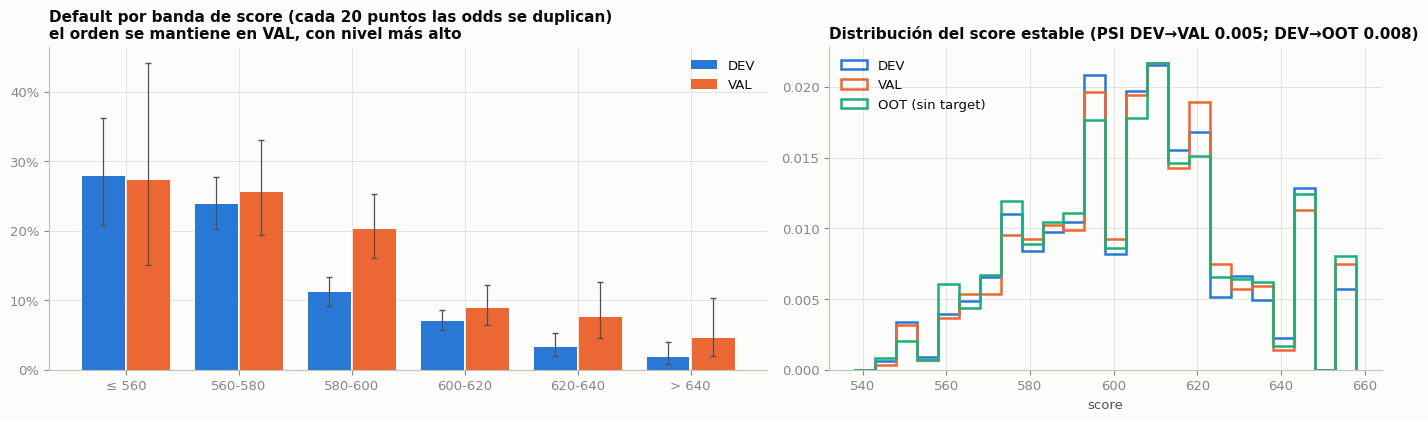

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.3), gridspec_kw={"width_ratios": [1.3, 1]})
etq = ["≤ 560", "560-580", "580-600", "600-620", "620-640", "> 640"]
for s, col, desp in [("DEV", BLUE, -0.2), ("VAL", ORANGE, 0.2)]:
    t_ = tab_bandas[s]
    barras_con_ic(axes[0], etq, t_["default_rate"], t_["ic_inf"], t_["ic_sup"], col, desplazamiento=desp, etiqueta=s, valores=False)
axes[0].set_xticks(np.arange(len(etq)), etq); pct_axis(axes[0]); axes[0].legend(loc="upper right")
axes[0].set_title("Default por banda de score (cada 20 puntos las odds se duplican)\nel orden se mantiene en VAL, con nivel más alto")
rango = np.arange(s_dev.min() - 5, s_dev.max() + 10, 5)
for s_, col, et in [(s_dev, BLUE, "DEV"), (s_val, ORANGE, "VAL"), (s_oot, AQUA, "OOT (sin target)")]:
    axes[1].hist(s_, bins=rango, density=True, histtype="step", lw=1.8, color=col, label=et)
axes[1].set_title(f"Distribución del score estable (PSI DEV→VAL {psi_score['DEV -> VAL']:.3f}; DEV→OOT {psi_score['DEV -> OOT (sin target)']:.3f})")
axes[1].set_xlabel("score"); axes[1].legend(loc="upper left")
fig.tight_layout(); savefig(fig, "fig21_bandas_score"); plt.show()

Se mide discriminación (Gini y KS), se compara contra dos referencias —el buró solo y una logística sobre las mismas variables continuas— y se revisa el comportamiento por banda de score. Del OOT solo se usa la distribución del score (PSI), sin target._LECTURA

## 6. Calibración: la PD de desarrollo no es la PD de producción

In [13]:
filas = []
for s, d in muestras.items():
    banda = pd.cut(pd.Series(card.score(d), index=d.index), bandas).astype(str)
    g = pd.DataFrame({"banda": banda, "pd": card.predict_pd(d), "y": d[T]}).groupby("banda", sort=False)
    t_ = g.agg(creditos=("y", "size"), pd_desarrollo=("pd", "mean"), default_observado=("y", "mean"))
    t_ = t_.reindex([str(c) for c in pd.cut(pd.Series(dtype=float), bandas).cat.categories])
    t_["observado_sobre_predicho"] = t_["default_observado"] / t_["pd_desarrollo"]
    filas.append(t_.assign(muestra=s))
calib = pd.concat(filas)
display(calib)
calib.to_csv(cfg.TABLES / "scorecard_calibracion_desarrollo.csv")
for s, d in muestras.items():
    print(f"{s}: PD media de desarrollo {card.predict_pd(d).mean():.1%} vs default observado {d[T].mean():.1%} (observado / predicho = {d[T].mean() / card.predict_pd(d).mean():.2f})")

,creditos,pd_desarrollo,default_observado,observado_sobre_predicho,muestra
banda,,,,,
"(-inf, 560.0]",129,0.3351,0.2791,0.8328,DEV
"(560.0, 580.0]",483,0.2110,0.2381,1.1283,DEV
"(580.0, 600.0]",881,0.1214,0.1112,0.9164,DEV
"(600.0, 620.0]",1140,0.0655,0.0702,1.0721,DEV
"(620.0, 640.0]",491,0.0369,0.0326,0.8821,DEV
"(640.0, inf]",319,0.0198,0.0188,0.9478,DEV
"(-inf, 560.0]",33,0.3369,0.2727,0.8094,VAL
"(560.0, 580.0]",156,0.2136,0.2564,1.2002,VAL
"(580.0, 600.0]",291,0.1220,0.2027,1.6623,VAL


DEV: PD media de desarrollo 10.2% vs default observado 10.2% (observado / predicho = 1.00)
VAL: PD media de desarrollo 9.9% vs default observado 14.0% (observado / predicho = 1.41)


**El orden funciona; el nivel no.** En DEV la PD predicha coincide con la observada (observado/predicho entre 0.83 y 1.13, y 1.00 en el agregado, como corresponde a la muestra de ajuste). En VAL el modelo predice 9.9% y se observa 14.0%: **subestima 41%**. Además el desvío no es parejo: crece en las bandas altas (2.06 en 620-640 y 2.38 sobre 640) y casi no existe en la banda más baja (0.81).

*Consecuencias para 6.7 y 6.9:*
1. La **escala de puntos queda congelada**; lo que se recalibra es la tabla score → PD. Así el punto de corte y las bandas no se mueven cada vez que cambia el nivel de riesgo.
2. Como el desvío no es un corrimiento paralelo, la recalibración debe ajustar **intercepto y pendiente** (Platt) y compararse contra isotónica, no un simple sumando al intercepto.
3. El motor de decisión y el Expected Loss deben usar la **PD recalibrada**, nunca la de desarrollo: con la PD de desarrollo, la pérdida esperada de la cartera quedaría subestimada en aproximadamente el mismo 40%.

## 7. Sesgo de selección: sensibilidad con reject inference

El scorecard se ajusta solo con aprobados (known good/bad), así que hereda la selección de la política histórica. 6.2 mostró que ese filtro fue débil (AUC de la aprobación 0.62, con aprobaciones en todo el rango de score), de modo que el sesgo esperado es moderado. Aquí se mide cuánto cambiaría el modelo bajo tres supuestos sobre los rechazados, con **aumentación difusa**: cada rechazado entra dos veces, como bueno y como malo, con pesos (1 − p, p), donde p es la PD del scorecard multiplicada por un factor de castigo.

In [14]:
rechazados = features.build_features(raw[raw[cfg.APPROVED_FLAG].eq(0) & (raw[cfg.DATE_COL] <= cfg.TEMPORAL_SPLITS["DEV"][1])])
print(f"Rechazados de 2021-2023: {len(rechazados):,} | PD de desarrollo media: rechazados {card.predict_pd(rechazados).mean():.1%} vs aprobados {pd_dev.mean():.1%}")
filas = [{"escenario": "Sin reject inference (scorecard A)", **{f"coef_{v}": card.coefs[v] for v in card.variables},
          "spearman_score_dev_vs_A": 1.0, "gini_val": validation.gini(val[T], pd_val)}]
for infl in [1.0, 1.5, 2.0]:
    datos, pesos = sc.fuzzy_augmentation(dev, rechazados, card, inflation=infl)
    card_ri, _ = sc.fit_scorecard(datos, card.variables, tramos, sample_weight=pesos)
    filas.append({"escenario": f"Aumentación difusa, rechazados {infl:.1f}x la PD del modelo",
                  **{f"coef_{v}": card_ri.coefs[v] for v in card.variables},
                  "spearman_score_dev_vs_A": stats.spearmanr(card.score(dev, exact=True), card_ri.score(dev, exact=True))[0],
                  "gini_val": validation.gini(val[T], card_ri.predict_pd(val))})
reject = pd.DataFrame(filas).set_index("escenario")
display(reject)
reject.to_csv(cfg.TABLES / "scorecard_reject_inference.csv")

Rechazados de 2021-2023: 711 | PD de desarrollo media: rechazados 12.6% vs aprobados 10.2%


,coef_bureau_score,coef_dti_post,coef_ahorro_sobre_monto,spearman_score_dev_vs_A,gini_val
escenario,,,,,
Sin reject inference (scorecard A),-1.0373,-1.0345,-0.8880,1.0000,0.3485
"Aumentación difusa, rechazados 1.0x la PD del modelo",-1.0360,-1.0349,-0.8875,1.0000,0.3485
"Aumentación difusa, rechazados 1.5x la PD del modelo",-1.0970,-1.0673,-0.9277,0.9997,0.3498
"Aumentación difusa, rechazados 2.0x la PD del modelo",-1.1540,-1.0987,-0.9656,0.9996,0.3498


El scorecard se ajusta solo con aprobados (known good/bad), así que hereda la selección de la política histórica. 6.2 mostró que ese filtro fue débil (AUC de la aprobación 0.62, con aprobaciones en todo el rango de score), de modo que el sesgo esperado es moderado. Aquí se mide cuánto cambiaría el modelo bajo tres supuestos sobre los rechazados, con **aumentación difusa**: cada rechazado entra dos veces, como bueno y como malo, con pesos (1 − p, p), donde p es la PD del scorecard multiplicada por un factor de castigo._LECTURA

## 8. Razones de decisión (reason codes)

Las razones son las características que más puntos le restan a la solicitud frente a su mejor tramo. Es lo que devuelve la API en `reason_codes` (6.13, 6.16 del enunciado) y lo que sustenta un rechazo explicable ante el cliente y ante auditoría. Cuando el dato falta, la razón lo dice de forma distinta: no es lo mismo "score bajo" que "sin score".

In [15]:
orden = np.argsort(s_val)
ejemplos = val.iloc[[orden[-1], orden[len(orden) // 2], orden[0]]].copy()
sin_score = val[val["bureau_score"].isna()].head(1)
ejemplos = pd.concat([ejemplos, sin_score])
ejemplos.index = ["Score más alto de VAL", "Score mediano de VAL", "Score más bajo de VAL", "Sin score de buró"]
detalle_ej = card.points_frame(ejemplos).add_prefix("puntos_")
detalle_ej["score"] = card.score(ejemplos)
detalle_ej["pd_desarrollo"] = card.predict_pd(ejemplos)
detalle_ej["razones"] = [" | ".join(r) for r in card.reason_codes(ejemplos, n=3)]
display(pd.concat([ejemplos[card.variables], detalle_ej], axis=1))

,bureau_score,dti_post,ahorro_sobre_monto,puntos_bureau_score,puntos_dti_post,puntos_ahorro_sobre_monto,score,pd_desarrollo,razones
Score más alto de VAL,835.0000,0.2654,1.3925,239,207,207,653,0.0158,
Score mediano de VAL,719.0000,0.7650,0.7075,212,185,207,604,0.0798,Score de buró bajo | Carga de deuda post-crédi...
Score más bajo de VAL,582.0000,0.7214,0.1039,169,185,189,543,0.4187,Score de buró bajo | Carga de deuda post-crédi...
Sin score de buró,NaN,0.7663,0.9008,199,185,207,591,0.1197,Score de buró no disponible (re-consultar) | C...


**Cuatro casos reales de VAL.** El mejor score (653) llega al máximo en las tres características y no tiene razones que reportar; el mediano (604) pierde puntos por buró y capacidad; el peor (543) acumula las tres razones y tiene una PD de desarrollo de 42%. La solicitud sin score de buró queda en 591 puntos con la razón explícita de re-consultar el buró, que es justo la acción operativa que pide la política de 6.1.

---

## 9. Resumen y trazabilidad de 6.5

| Requisito del enunciado | Dónde se cumple |
|---|---|
| Binning + WOE + IV + regresión logística | §1 a §4 · `src/scorecard.py` · `tables/scorecard_seleccion_univariada.csv` |
| Monotonicidad | Regla del binning (§1) y prueba `test_binning_respeta_minimos_y_monotonia` |
| Bins pequeños | Mínimos de 5% de la muestra y 15 defaults por tramo (§1) |
| Missing bins | §2 · WOE neutral con evidencia de 6.3 · `tables/scorecard_faltantes_woe.csv` |
| Estabilidad | §2 (PSI por tramo, S4-S6) y §5 (PSI del score, Gini año por año) |
| Justificar selección y eliminación de variables | §2 (S1-S7), §3 (stepwise, especificaciones y sensibilidad) |
| Scorecard final documentado | §4 · `tables/scorecard_puntos.csv` · artefacto `models/scorecard_pd_v1.json` |
| Escala: Base Score, Base Odds y PDO | §4 · 600 puntos = odds 10:1, PDO 20 |

**Lo que queda explícitamente fuera de 6.5:** la comparación contra Random Forest, XGBoost y LightGBM (6.6), la recalibración y las métricas sobre OOT (6.7), SHAP y fairness (6.8) y el punto de corte con su curva de trade-off (6.9).

**Limitaciones declaradas:** (i) un solo scorecard para todos los canales y regiones, que 6.4 respalda porque el buró ordena igual en los cuatro canales; (ii) la PD del scorecard es de desarrollo y **no debe usarse sin recalibrar**; (iii) tres características son pocas, pero es lo que la evidencia sostiene: agregar variables sin señal sube el Gini de DEV y lo baja fuera de muestra, como muestra el ejercicio con la mora previa.